In [1]:
import numpy as np
from PIL import Image
import taichi as ti
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from utils import run_optimization, resample_polyline, get_area

ti.init(arch=ti.gpu)

[Taichi] version 1.7.3, llvm 15.0.1, commit 5ec301be, win, python 3.12.3
[Taichi] Starting on arch=cuda


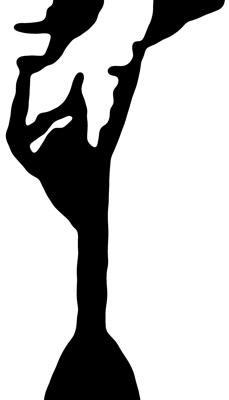

In [45]:
wall_image = Image.open('../input_images/九顿天窗_平滑.png')

wall_numpy = np.array(wall_image).T > 0  # 读取图片并转换为布尔数组
assert len(wall_numpy.shape) == 2, "Image must be grayscale"

wall_image_down_sampled = wall_image.convert('1').convert('RGB').resize((wall_image.width // 8, wall_image.height // 8))
wall_image_down_sampled

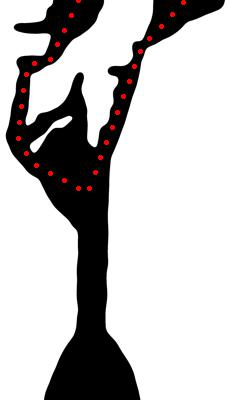

In [ ]:
from PIL import ImageDraw

def init_trajectory(sofa_w, sofa_h, control_point_num):  # 生成初始轨迹
    middle_rotation = -0.25 * np.pi
    xs, ys, rotations = resample_polyline([
        [625, 6, 0],
        [398, 479, 0],
        [219, 527, 0],
        [141, 1097, 0],
        [250, 1300, 0],
        [700, 1551, 0],
        [1136, 374, 0],
        [1467, 23, 0],
    ], control_point_num).T
    return xs, ys, rotations

sofa_w = 200   # 求解域的尺寸
sofa_h = 200   # 求解域的尺寸

xs, ys, rotations = init_trajectory(  # 初始轨迹
    sofa_w=sofa_w,
    sofa_h=sofa_h,
    control_point_num=30,  # 轨迹的控制点数量
)

wall_image_down_sampled = wall_image.convert('1').convert('RGB').resize((wall_image.width // 8, wall_image.height // 8))
draw = ImageDraw.Draw(wall_image_down_sampled)
for x, y in zip(xs, ys):
    draw.ellipse((x / 8 - 2, y / 8 - 2, x / 8 + 2, y / 8 + 2), fill='red')  # 画单个红点
wall_image_down_sampled

In [ ]:
21 / 219  # 对应实际比例

0.0958904109589041

In [47]:
wall_taichi = ti.field(dtype=ti.i8, shape=wall_numpy.shape)
wall_taichi.from_numpy(wall_numpy.astype(np.int8))

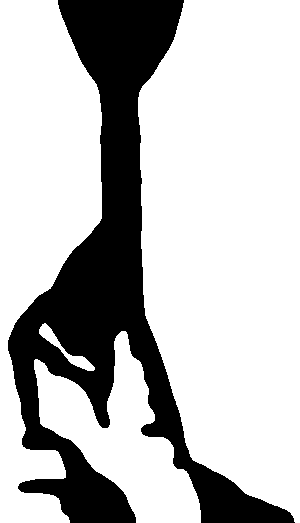

In [ ]:
# 可视化墙（白色区域为墙）

from utils import test_forbidden_function

@ti.func
def is_forbidden(x1, y1, x2, y2):  # 指定哪里是墙
    return wall_taichi[int(x2), int(y2)]

image = test_forbidden_function(
    is_forbidden,
    0, 1834, 0, 3200, [300, round(300 * 3200 / 1834)],
    # wall_normal=[0, 0.05]
)
Image.fromarray(np.array(image.T[::-1] * 255, dtype=np.uint8))

In [153]:
xs, ys, rotations = np.load('../trajectory/九顿天窗_1/sofa_4602.npy')

In [124]:
sofa_w = 400   # 求解域的尺寸
sofa_h = 200   # 求解域的尺寸

Initial survivors: 22608.794921875
iter 500 / 40000, maximal_area=22696.228515625
iter 1000 / 40000, maximal_area=22716.064453125
iter 1500 / 40000, maximal_area=22727.05078125
iter 2000 / 40000, maximal_area=22757.568359375
iter 2500 / 40000, maximal_area=22763.9765625
iter 3000 / 40000, maximal_area=22766.72265625
iter 3500 / 40000, maximal_area=22767.9453125
iter 4000 / 40000, maximal_area=22773.1328125
iter 4500 / 40000, maximal_area=22782.287109375
iter 5000 / 40000, maximal_area=22783.5078125
iter 5500 / 40000, maximal_area=22787.169921875
iter 6000 / 40000, maximal_area=22787.78125
iter 6500 / 40000, maximal_area=22788.6953125
iter 7000 / 40000, maximal_area=22789.001953125
iter 7500 / 40000, maximal_area=22789.458984375
iter 8000 / 40000, maximal_area=22789.611328125
iter 8500 / 40000, maximal_area=22790.375
iter 9000 / 40000, maximal_area=22790.83203125
iter 9500 / 40000, maximal_area=22792.052734375
iter 10000 / 40000, maximal_area=22792.205078125
iter 10500 / 40000, maximal_

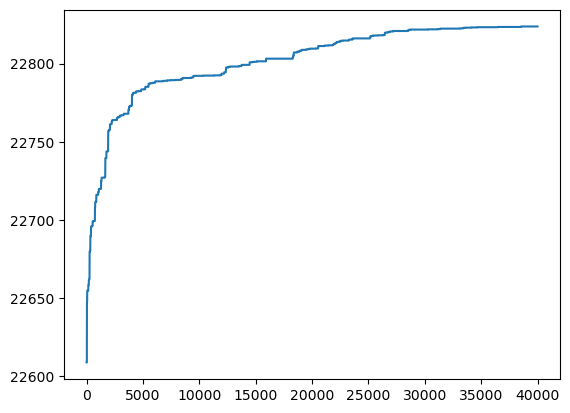

In [154]:
best_score, xs, ys, rotations, sofa, maximal_area_record = run_optimization(
    is_forbidden,
    # xs,
    # ys,
    # rotations,
    initial_xs=zoom(xs, zoom=2, order=1),
    initial_ys=zoom(ys, zoom=2, order=1),
    initial_rotations=zoom(rotations, zoom=2, order=1),
    sofa_w=sofa_w,
    sofa_h=sofa_h,
    mutation_sigma_pos = 2,  # 变异率
    mutation_sigma_rotation = 0.004,  # 变异率
    iterations = 40000,  # 200000
    trajectory_upsampling=101,  # 41 101
    resolution=1024,  # 1024 2000
    print_every=500,  # 1000
    save_image_every=83,
    save_image_path='../images/九顿天窗_1/sofa_',
    save_image_start_id=4602,
    save_trajectory_path='../trajectory/九顿天窗_1/sofa_'
)
print(f"Estimated maximal sofa area (by sampling): {best_score:.5f}")
# save mask image as PNG if pillow is available

img = (sofa * 255).astype(np.uint8)
im = Image.fromarray(img.T[::-1])
im.save('../sofa_survivors.png')
plt.plot(maximal_area_record)

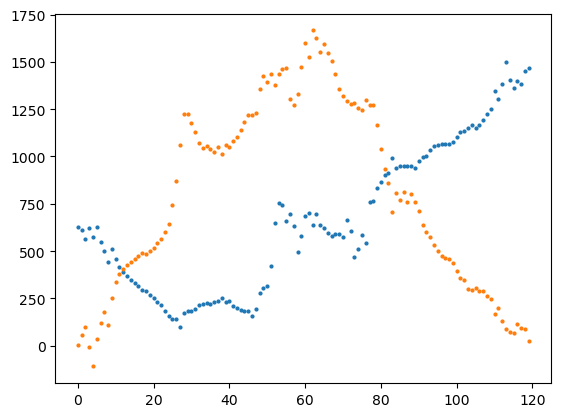

In [155]:
plt.plot(xs, 'o', markersize=2)
plt.plot(ys, 'o', markersize=2)

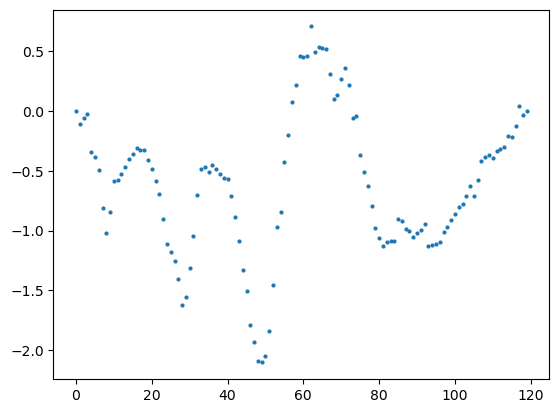

In [156]:
plt.plot(rotations, 'o', markersize=2)

In [157]:
np.mean((rotations - np.mean(rotations)) ** 2) ** 0.5  # 标准差

0.5987775060916588